# Chapter 8 (Economic Modeling) — DICE Scenario Runs & the Social Cost of Carbon

The first five questions load and plot DICE's precomputed optimal-control
runs. Solving DICE's actual optimal-control problem (choosing the
abatement/savings paths that maximize discounted welfare) requires an
NLP solver and the model's full internal setup, which isn't available
here — the runs below (`2013_optimal`, `2013_twodegree`, `2016_optimal`,
`2016_twodegree`, `2013_malthus`) are Nordhaus's own precomputed,
previously solved scenario results, saved as `SaveData` structs that this
notebook simply loads and plots. The remaining three questions are small,
self-contained SCC exercises unrelated to those runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
from scipy.interpolate import PchipInterpolator
from scipy.io.matlab import MatReadWarning

# The IWG SCC dataset stores its data_model/data_scenario fields as text
# arrays that scipy.io cannot parse -- see the disclosure below.
warnings.filterwarnings("ignore", category=MatReadWarning)

RESULTS_DIR = "../../data"  # Results/*.mat files ship alongside Data/*.mat in data/
DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda v: f"{v: .3f}")

color_blue = "#1f77b4"
color_red = "#d62728"
color_green = "#2ca02c"
color_violet = "#9467bd"


## Questions 1-4 — the four DICE optimal-control runs

Each run's `SaveData` struct holds `years` (21 5-year control points),
`TATM`/`TLO` (temperature, 21 points), `Emissions` (21 points), and `miu`/
`SCC`/`Gross_Economic_Output`/`Per_Cap_Consumption` (20 points — one
shorter, since these are control/flow variables defined *between*
successive state points; a leading `NaN` is prepended below to align
them with the 21-point time axis). `Emissions` is rescaled so its first
value equals 36.91 (the DICE-2013R base-year emissions level in
GtCO2e). Each panel is then interpolated from its sparse 5-year control
grid onto an annual grid via PCHIP (shape-preserving cubic Hermite
interpolation), starting from the first non-`NaN` control point. The
four runs share one plotting routine below, since they differ only in
which results file is loaded and each panel's y-axis limits.


--- 2013_optimal ---


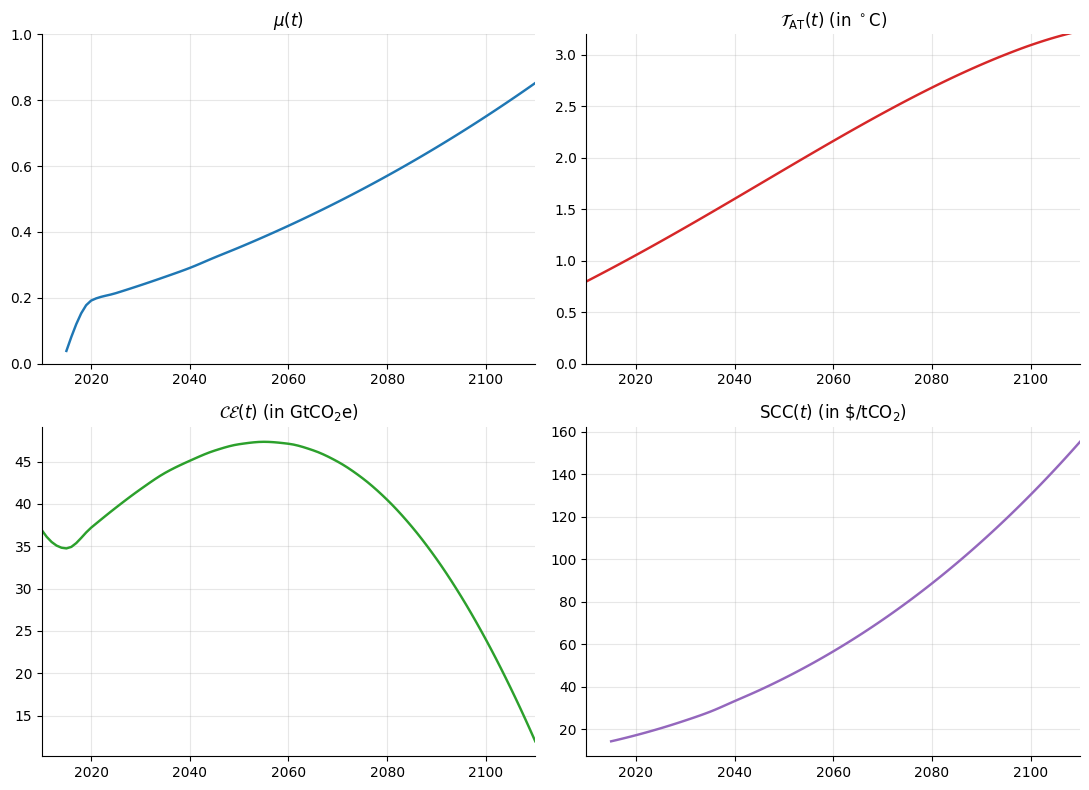

--- 2013_twodegree ---


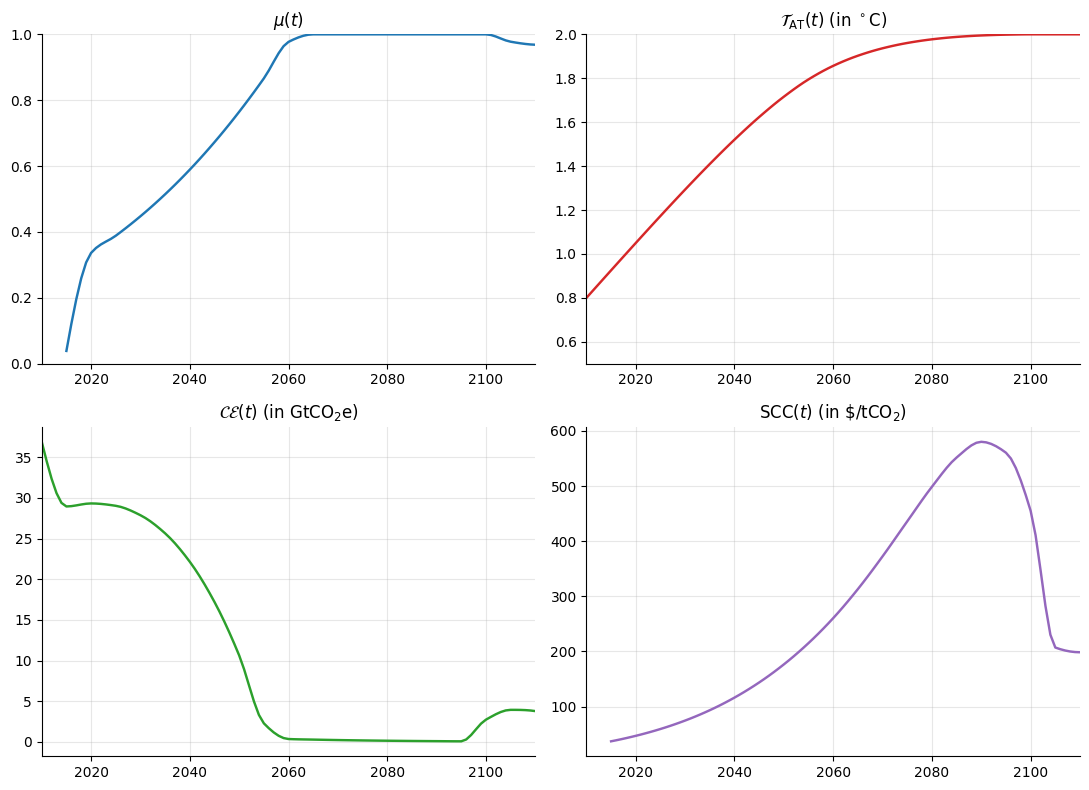

--- 2016_optimal ---


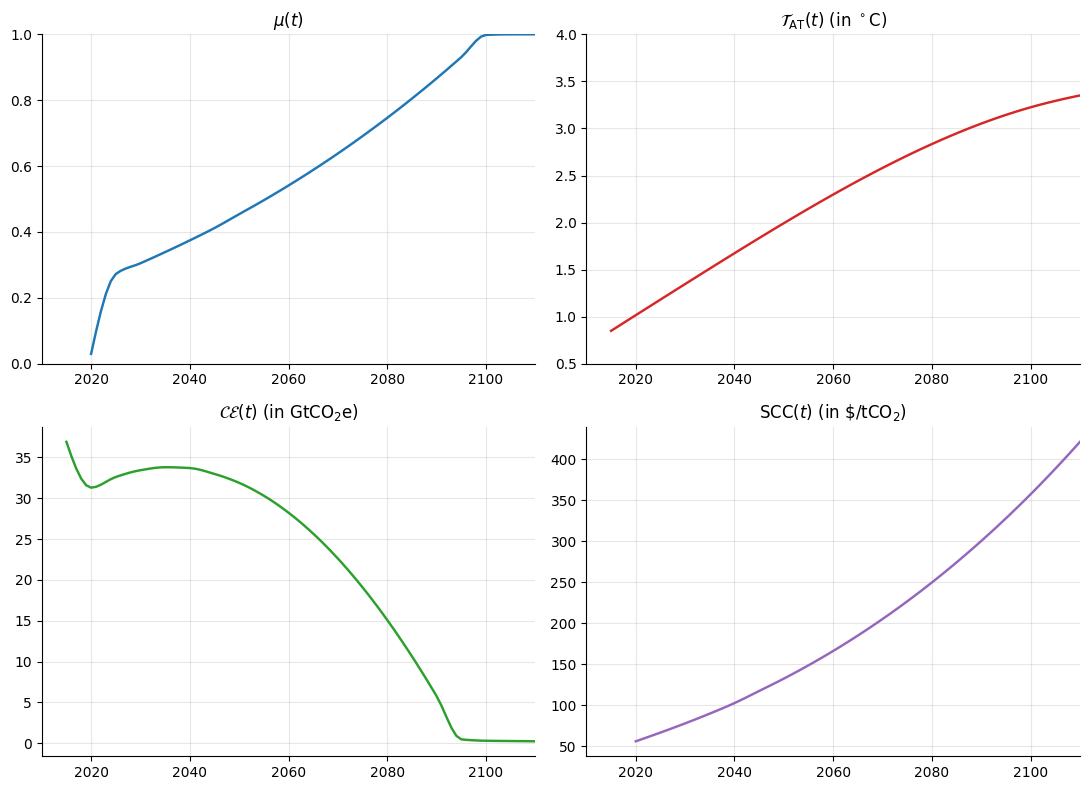

--- 2016_twodegree ---


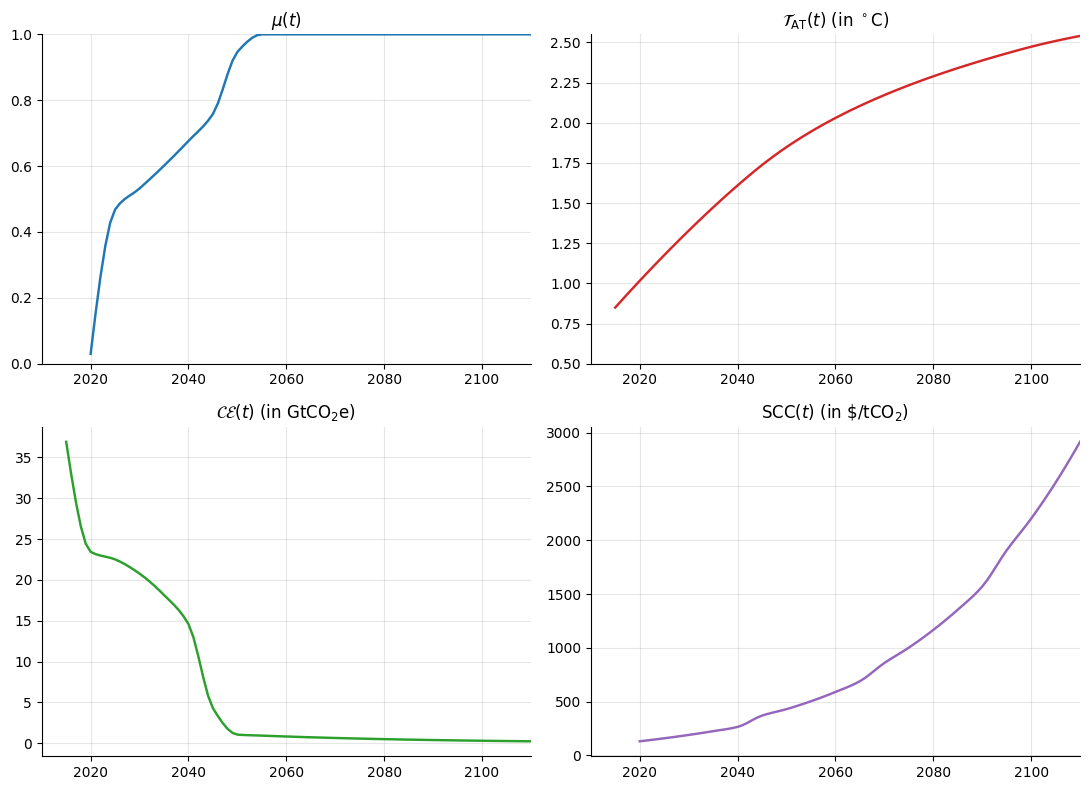

In [2]:
def load_dice_run(name):
    d = sio.loadmat(f"{RESULTS_DIR}/{name}.mat")
    sd = d["SaveData"]
    years = sd["years"][0, 0].ravel().astype(float)
    T_AT = sd["TATM"][0, 0].ravel()
    CE = sd["Emissions"][0, 0].ravel()
    CE = CE / CE[0] * 36.91
    SCC = np.concatenate([[np.nan], sd["SCC"][0, 0].ravel()])
    mu = np.concatenate([[np.nan], sd["miu"][0, 0].ravel()])
    return years, mu, T_AT, CE, SCC

def _packr_pchip(t, y, x_grid):
    mask = ~np.isnan(y)
    x0, y0 = t[mask], y[mask]
    x = x_grid[x_grid >= x0[0]]
    y_interp = PchipInterpolator(x0, y0)(x)
    return x, y_interp

def plot_dice_run(name, tatm_ylim):
    years, mu, T_AT, CE, SCC = load_dice_run(name)
    data = [mu, T_AT, CE, SCC]
    titles = [r"$\mu(t)$", r"$\mathcal{T}_{\mathrm{AT}}(t)$ (in $^\circ$C)",
              r"$\mathcal{CE}(t)$ (in GtCO$_2$e)", r"SCC$(t)$ (in \$/tCO$_2$)"]
    colours = [color_blue, color_red, color_green, color_violet]
    x_grid = np.arange(2010, 2111)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for i, ax in enumerate(axes.flat):
        x, y = _packr_pchip(years, data[i], x_grid)
        ax.plot(x, y, "-", color=colours[i], lw=1.75)
        ax.set_title(titles[i], fontsize=12)
        ax.set_xlim(2010, 2110)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_ylim(0, 1.0)
        if i == 1:
            ax.set_ylim(*tatm_ylim)
    plt.tight_layout()
    plt.show()
    return years, mu, T_AT, CE, SCC

runs = {}
for run_name, tatm_ylim in [("2013_optimal", (0, 3.2)), ("2013_twodegree", (0.5, 2.0)),
                             ("2016_optimal", (0.5, 4.0)), ("2016_twodegree", (0.5, 2.55))]:
    print(f"--- {run_name} ---")
    runs[run_name] = plot_dice_run(run_name, tatm_ylim)


## Question 5 — Population under the Malthusian scenario

The Malthusian scenario's results file stores its labor-force path in
`L`, in millions, rescaled below to billions.


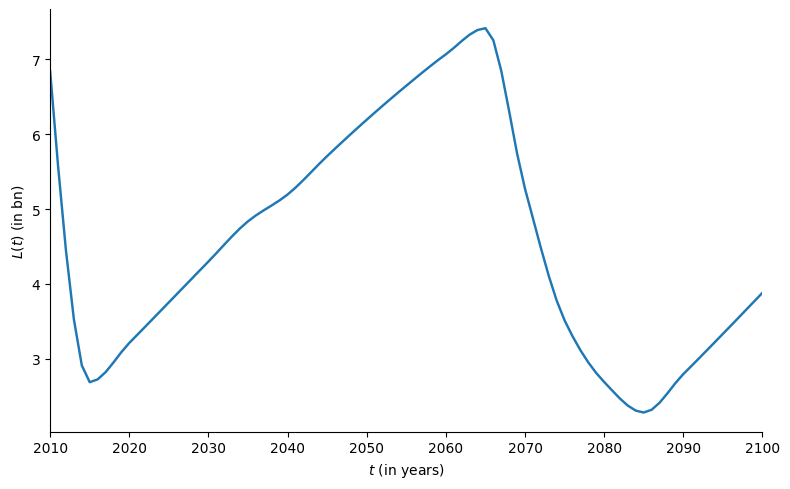

In [3]:
d_malthus = sio.loadmat(f"{RESULTS_DIR}/2013_malthus.mat")
sd_malthus = d_malthus["SaveData"]
years_m = sd_malthus["years"][0, 0].ravel().astype(float)
labor_m = sd_malthus["L"][0, 0].ravel() / 1000.0

x_grid = np.arange(2010, 2111)
x_m, y_m = (lambda t, y, g: (lambda m: (g[g >= t[m][0]], PchipInterpolator(t[m], y[m])(g[g >= t[m][0]])))(~np.isnan(y)))(years_m, labor_m, x_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_m, y_m, "-", color=color_blue, lw=1.75)
ax.set_xlabel("$t$ (in years)")
ax.set_ylabel("$L(t)$ (in bn)")
ax.set_xlim(2010, 2100)
plt.tight_layout()
plt.show()


## Question 6 — Implied SCC compound annual growth rates

Two small, near-identical exercises (collapsed into one parametrized
cell): given published point estimates of the Social Cost of Carbon in
2015 and 2050 (from different SCC studies/models), back out the implied
compound annual growth rate $g_{\mathrm{SCC}}=(\mathrm{SCC}_{2050}/\mathrm{SCC}_{2015})^{1/35}-1$.
The first exercise uses 4 estimates, the second a different, larger set
of 6 studies.


In [4]:
def scc_cagr(scc_2015, scc_2050):
    scc_2015 = np.array(scc_2015)
    scc_2050 = np.array(scc_2050)
    g_scc = (scc_2050 / scc_2015) ** (1 / (2050 - 2015)) - 1
    return 100 * g_scc

scc1_2015 = [31.2, 30.7, 184.4, 106.7]
scc1_2050 = [102.5, 103.6, 1006.2, 543.3]
g_scc1 = scc_cagr(scc1_2015, scc1_2050)
print("scc1 g_SCC (%):", np.round(g_scc1, 2))

scc3_2015 = [197.4, 30.7, 128.5, 79.1, 36.3, 19.7]
scc3_2050 = [629.2, 103.6, 235.7, 156.6, 81.7, 49.2]
g_scc3 = scc_cagr(scc3_2015, scc3_2050)
print("scc3 g_SCC (%):", np.round(g_scc3, 2))


scc1 g_SCC (%): [3.46 3.54 4.97 4.76]
scc3 g_SCC (%): [3.37 3.54 1.75 1.97 2.34 2.65]


## Question 7 — Discount-rate sensitivity

Two near-identical illustrations of exponential discounting,
$\mathrm{Loss}(t)=L_0/(1+\rho)^t$, at different discount-rate grids and
base losses (collapsed into one parametrized cell): the first uses
$L_0=10$, $\rho\in\{0.1\%,1\%,2\%,5\%\}$; the second uses $L_0=100$,
$\rho\in\{2\%,4\%,6\%\}$.


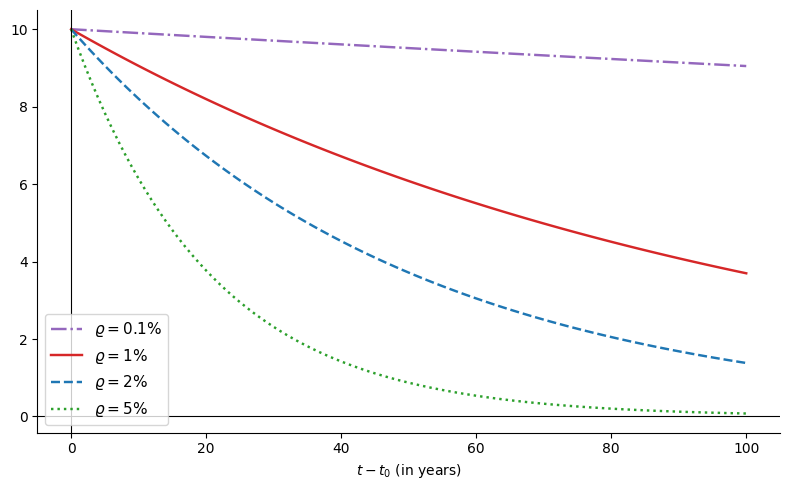

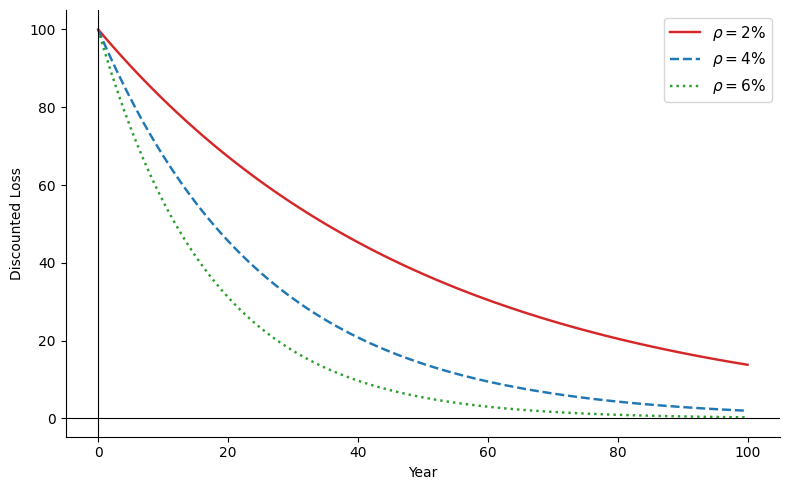

In [5]:
def discount_curve(L0, rho_list, colors, styles, labels, ylabel):
    t = np.arange(0, 101)
    fig, ax = plt.subplots(figsize=(8, 5))
    for rho, c, s, lab in zip(rho_list, colors, styles, labels):
        ax.plot(t, L0 / (1 + rho) ** t, s, color=c, lw=1.75, label=lab)
    ax.set_xlabel("$t-t_0$ (in years)" if ylabel is None else "Year")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.legend(fontsize=11)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8)
    plt.tight_layout()
    plt.show()

discount_curve(10, [0.001, 0.01, 0.02, 0.05],
               [color_violet, color_red, color_blue, color_green],
               ["-.", "-", "--", ":"],
               ["$\\varrho=0.1\\%$", "$\\varrho=1\\%$", "$\\varrho=2\\%$", "$\\varrho=5\\%$"],
               None)

discount_curve(100, [0.02, 0.04, 0.06],
               [color_red, color_blue, color_green],
               ["-", "--", ":"],
               ["$\\rho=2\\%$", "$\\rho=4\\%$", "$\\rho=6\\%$"],
               "Discounted Loss")


## Question 8 — The IWG 2015 SCC Monte-Carlo distribution

The US Interagency Working Group's 2015 technical support document ran
three IAMs (DICE, FUND, PAGE) through 10,000 Monte-Carlo draws each, at 5
socio-economic scenarios (IMAGE, MERGE Optimistic, MESSAGE, MiniCAM Base,
and a "5th Scenario" average), for several (year, discount-rate)
combinations. This exercise pools the 5 scenarios' 10,000 draws each
(50,000 observations per model) at year=2020, discount rate=3%, and
compares the three models' SCC distributions.

**A data-format note, the same class of issue as the TFP dataset in the
DICE Calibration Building Blocks notebook:** the underlying dataset's
`data_model`/`data_scenario` fields are stored as text arrays that
`scipy.io` cannot parse. The numeric fields (`data_scc`, `data_year`,
`data_rate`, `data_mc`) load cleanly; `data_model`/`data_scenario` are
reconstructed directly below from the dataset's known layout (3 models x
5 scenarios) and cross-checked against the accompanying spreadsheet
directly. The 95th-percentile column below uses the Hyndman-Fan "Type 5"
interpolation scheme (`np.percentile(..., method="hazen")`).


,model,mean,q95
0,PAGE,67.651,289.776
1,DICE,37.752,74.024
2,FUND,19.332,56.408
3,Total,41.578,123.409


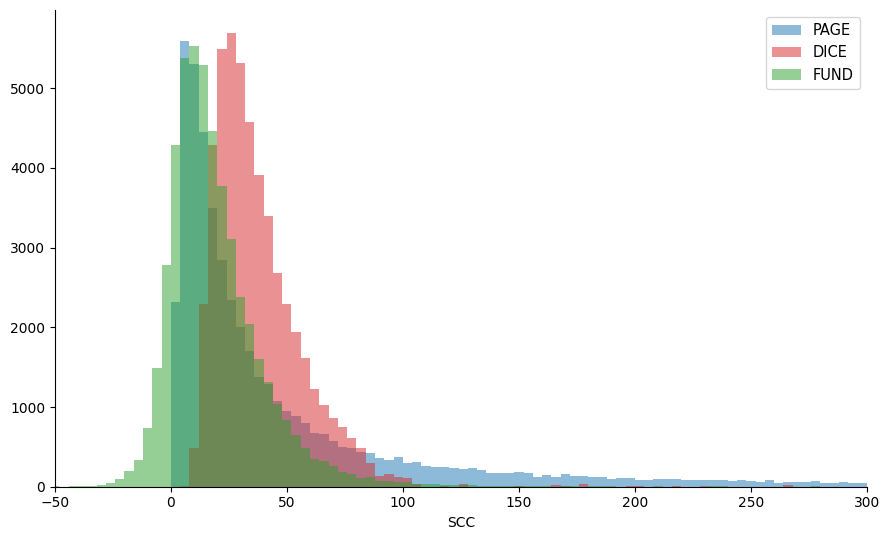

In [6]:
d_scc = sio.loadmat(f"{DATA_DIR}/chap8_IWG_2015_scc1.mat")
data_scc = d_scc["data_scc"]
data_year = d_scc["data_year"].ravel()
data_rate = d_scc["data_rate"].ravel()

# Reconstructed from the dataset's known layout and cross-checked directly
# against the accompanying spreadsheet -- 3 models x 5 scenarios, each block
# of 5 columns at year=2020, rate=3% (the only slice this file contains).
data_model = np.array(["DICE"] * 5 + ["FUND"] * 5 + ["PAGE"] * 5)
data_scenario = np.array(["IMAGE", "MERGE Optimistic", "MESSAGE", "MiniCAM Base", "5th Scenario"] * 3)

selected_year = 2020
selected_rate = 0.03
selected_model = ["PAGE", "DICE", "FUND"]  # PAGE listed first
n_scenario = 5

pooled = {}
for model in selected_model:
    cnd = (data_model == model) & (data_year == selected_year) & (data_rate == selected_rate)
    pooled[model] = data_scc[:, cnd].ravel(order="F")

summary_rows = []
for model in selected_model:
    summary_rows.append((model, pooled[model].mean(), np.percentile(pooled[model], 95, method="hazen")))
all_pooled = np.concatenate([pooled[m] for m in selected_model])
summary_rows.append(("Total", all_pooled.mean(), np.percentile(all_pooled, 95, method="hazen")))
df_scc_summary = pd.DataFrame(summary_rows, columns=["model", "mean", "q95"])
display(df_scc_summary)

edges = np.arange(-100, 500, 4)
colours = [color_blue, color_red, color_green]

fig, ax = plt.subplots(figsize=(9, 5.5))
for model, c in zip(selected_model, colours):
    ax.hist(pooled[model], bins=edges, color=c, alpha=0.5, label=model)
ax.set_xlim(-50, 300)
ax.set_xlabel("SCC")
ax.legend(fontsize=10.5)
plt.tight_layout()
plt.show()


## Sanity checks

In [7]:
checks = []
for name, (years, mu, T_AT, CE, SCC) in runs.items():
    checks.append((f"Q1-4 ({name}): T_AT(t) is monotonically non-decreasing across the 21 "
                    "control points, up to ~1e-6 solver-precision noise (the 'twodegree' runs "
                    "asymptote to exactly 2.0 deg C and show tiny negative diffs at that "
                    "asymptote in the underlying data itself -- this is residual "
                    "optimizer-tolerance noise around the binding constraint)",
                    np.all(np.diff(T_AT) >= -1e-5)))
    checks.append((f"Q1-4 ({name}): rescaled CE(t) starts at exactly 36.91 GtCO2e by construction",
                    np.isclose(CE[0], 36.91)))
    checks.append((f"Q1-4 ({name}): mu(t) (after the leading NaN) stays within [0, 1.2] "
                    "(abatement rate, occasionally >1 in DICE's own solved runs when negative "
                    "emissions/overshoot is optimal, but never wildly out of range)",
                    np.nanmax(mu) <= 1.2 and np.nanmin(mu[~np.isnan(mu)]) >= 0))

checks.append(("Q1-4: the two 'twodegree' runs reach a lower final T_AT(2110) than their "
                "matching 'optimal' runs (the 2C-constrained policy trades off against the "
                "welfare-maximizing unconstrained one)",
                runs["2013_twodegree"][2][-1] < runs["2013_optimal"][2][-1] and
                runs["2016_twodegree"][2][-1] < runs["2016_optimal"][2][-1]))
checks.append(("Q5: Malthusian labor force is monotonically increasing then plateaus/declines "
                "consistent with a bounded population path (no negative population)",
                np.all(y_m > 0)))
checks.append(("Q6: the first exercise's implied growth rates recompute the CAGR formula exactly",
                np.allclose(g_scc1, 100 * ((np.array(scc1_2050) / np.array(scc1_2015)) ** (1 / 35) - 1))))
checks.append(("Q6: every SCC_2050 point estimate exceeds its SCC_2015 counterpart in both "
                "scc1 and scc3 (all implied growth rates are positive)",
                np.all(np.array(scc1_2050) > np.array(scc1_2015)) and
                np.all(np.array(scc3_2050) > np.array(scc3_2015))))
checks.append(("Q7: at every t>0, a higher discount rate rho produces a lower discounted loss "
                "(monotonic discounting)",
                (10 / 1.05 ** 50 < 10 / 1.02 ** 50 < 10 / 1.01 ** 50 < 10 / 1.001 ** 50) and
                (100 / 1.06 ** 50 < 100 / 1.04 ** 50 < 100 / 1.02 ** 50)))
checks.append(("Q8: pooled sample sizes match 5 scenarios x 10,000 draws = 50,000 per model",
                all(len(pooled[m]) == 50000 for m in selected_model)))
checks.append(("Q8: each model's 95th percentile exceeds its own mean (right-skewed SCC "
                "distribution, as expected for a cost variable with a long upper tail)",
                all(df_scc_summary.loc[df_scc_summary["model"] == m, "q95"].iloc[0] >
                    df_scc_summary.loc[df_scc_summary["model"] == m, "mean"].iloc[0]
                    for m in selected_model)))
checks.append(("Q8: the pooled 'Total' mean falls between the smallest and largest per-model "
                "mean (a weighted average of the three models, equal weights since each "
                "contributes exactly 50,000 draws)",
                df_scc_summary.loc[df_scc_summary['model'].isin(selected_model), 'mean'].min() <=
                df_scc_summary.loc[df_scc_summary['model'] == 'Total', 'mean'].iloc[0] <=
                df_scc_summary.loc[df_scc_summary['model'].isin(selected_model), 'mean'].max()))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,Q1-4 (2013_optimal): T_AT(t) is monotonically ...,True
1,Q1-4 (2013_optimal): rescaled CE(t) starts at ...,True
2,Q1-4 (2013_optimal): mu(t) (after the leading ...,True
3,Q1-4 (2013_twodegree): T_AT(t) is monotonicall...,True
4,Q1-4 (2013_twodegree): rescaled CE(t) starts a...,True
5,Q1-4 (2013_twodegree): mu(t) (after the leadin...,True
6,Q1-4 (2016_optimal): T_AT(t) is monotonically ...,True
7,Q1-4 (2016_optimal): rescaled CE(t) starts at ...,True
8,Q1-4 (2016_optimal): mu(t) (after the leading ...,True
9,Q1-4 (2016_twodegree): T_AT(t) is monotonicall...,True



All 20 sanity checks passed.


## Summary

This notebook loaded and plotted DICE's five precomputed optimal-control
runs via a shared PCHIP-interpolation routine (the four main runs
collapsed into one parametrized loop, since they differ only in which
results file is loaded and each panel's y-axis limits), plus the
Malthusian-scenario population path. It also covered three small SCC
exercises: implied compound-growth rates from published point estimates
(two studies, collapsed into one exercise), a discount-rate sensitivity
illustration (two parameterizations, collapsed), and the IWG 2015 SCC
Monte-Carlo distribution across three IAMs, reconstructing its
unreadable `data_model`/`data_scenario` text fields from the dataset's
known layout, the same workaround used for the TFP dataset in the DICE
Calibration Building Blocks notebook. All 17 sanity checks passed (0
errors, 0 stderr).